In [1]:
import pandas as pd
import numpy as np
from numpy import transpose as T
import glob
import os
import cartopy
import cartopy.crs as ccrs
import matplotlib
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import geopandas as gpd
from scipy.optimize import curve_fit
from netCDF4 import Dataset
import scipy
from scipy import stats
from scipy.ndimage import distance_transform_edt
from datetime import datetime,timedelta
from numpy import genfromtxt as gftxt
import regionmask
from pyproj import Transformer
from datetime import datetime,timedelta
import sys
from pathlib import Path

In [2]:
sys.path.append(str(Path.cwd().parents[1]))
from utils.grid_map_functions import(land_masking, defining_grids)

map_projection = ccrs.NorthPolarStereo()

x_grid_edge_25,y_grid_edge_25,new_x_edge_25,new_y_edge_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'edge')
x_grid_edge_20,y_grid_edge_20,new_x_edge_20,new_y_edge_20 = defining_grids(map_projection,[-180, 180, 90, 65],20000,'edge')
x_grid_edge_15,y_grid_edge_15,new_x_edge_15,new_y_edge_15 = defining_grids(map_projection,[-180, 180, 90, 65],15000,'edge')
x_grid_edge_10,y_grid_edge_10,new_x_edge_10,new_y_edge_10 = defining_grids(map_projection,[-180, 180, 90, 65],10000,'edge')
x_grid_edge_5,y_grid_edge_5,new_x_edge_5,new_y_edge_5 = defining_grids(map_projection,[-180, 180, 90, 65],5000,'edge')

x_grid_centre_25,y_grid_centre_25,new_x_centre_25,new_y_centre_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'centre')
x_grid_centre_20,y_grid_centre_20,new_x_centre_20,new_y_centre_20 = defining_grids(map_projection,[-180, 180, 90, 65],20000,'centre')
x_grid_centre_15,y_grid_centre_15,new_x_centre_15,new_y_centre_15 = defining_grids(map_projection,[-180, 180, 90, 65],15000,'centre')
x_grid_centre_10,y_grid_centre_10,new_x_centre_10,new_y_centre_10 = defining_grids(map_projection,[-180, 180, 90, 65],10000,'centre')
x_grid_centre_5,y_grid_centre_5,new_x_centre_5,new_y_centre_5 = defining_grids(map_projection,[-180, 180, 90, 65],5000,'centre')

land_mask_25 = land_masking(new_x_centre_25,new_y_centre_25,map_projection)
land_mask_20 = land_masking(new_x_centre_20,new_y_centre_20,map_projection)
land_mask_15 = land_masking(new_x_centre_15,new_y_centre_15,map_projection)
land_mask_10 = land_masking(new_x_centre_10,new_y_centre_10,map_projection)
land_mask_5 = land_masking(new_x_centre_5,new_y_centre_5,map_projection)

from utils.stats_functions import(absdiff,corr,rmsd)

base_dir = ('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/')

In [3]:
transformer = Transformer.from_crs(map_projection, "EPSG:4326", always_xy=True)
lon0, lat0 = transformer.transform(new_x_centre_25.ravel(), new_y_centre_25.ravel())
lon_25km = lon0.reshape(new_x_centre_25.shape)
lat_25km = lat0.reshape(new_y_centre_25.shape)

lon0, lat0 = transformer.transform(new_x_centre_20.ravel(), new_y_centre_20.ravel())
lon_20km = lon0.reshape(new_x_centre_20.shape)
lat_20km = lat0.reshape(new_y_centre_20.shape)

lon0, lat0 = transformer.transform(new_x_centre_15.ravel(), new_y_centre_15.ravel())
lon_15km = lon0.reshape(new_x_centre_15.shape)
lat_15km = lat0.reshape(new_y_centre_15.shape)

lon0, lat0 = transformer.transform(new_x_centre_10.ravel(), new_y_centre_10.ravel())
lon_10km = lon0.reshape(new_x_centre_10.shape)
lat_10km = lat0.reshape(new_y_centre_10.shape)

lon0, lat0 = transformer.transform(new_x_centre_5.ravel(), new_y_centre_5.ravel())
lon_5km = lon0.reshape(new_x_centre_5.shape)
lat_5km = lat0.reshape(new_y_centre_5.shape)

lats_bands = {'5km':lat_5km,'10km':lat_10km,'15km':lat_15km,'20km':lat_20km,'25km':lat_25km}
land_masks = {'5km':land_mask_5,'10km':land_mask_10,'15km':land_mask_15,'20km':land_mask_20,'25km':land_mask_25}

In [4]:
def add_land_buffer_distance(land_mask, grid_spacing_km, buffer_km):
    """
    Create buffer based on real distance (km)
    """
    # दूरी from land: compute distance from NON-land
    distance = distance_transform_edt(~land_mask) * grid_spacing_km
    
    # mask where within buffer distance
    buffer_mask = distance <= buffer_km
    
    return land_mask | buffer_mask

def retrieving_fractions(input_folder,yrs):
    fractions = {}
    for array in input_folder:
        fraction0 = np.load(array)
        fraction = np.where(land_mask_buffered, np.nan, fraction0)
        fname = os.path.basename(array)
        date = fname.split('_')[0]
        year = str(date[0:4])
        month = str(date[4:6])
        if year in yrs:
            if year == '2018' and int(month) < 10:# don't include jan - apr for 2018
                continue
            if year == '2025' and int(month) > 4: # don't include oct - dec for 2025
                continue
            fractions[date] = fraction
    return(fractions)

def simple_lat_counts(total_values,ice_mask,land_mask,lats, lat_min, lat_max):
    lat = lats.copy()
    # Set land values to nan so they do not bias the valid counts
    lat[land_mask] = np.nan
    lat[ice_mask] = np.nan
    
    vals = total_values.copy()
    vals[ice_mask] = np.nan
    
    if vals.shape != lat.shape:
        raise ValueError('Latitude and Values array must have the same shape')

    valid = (~np.isnan(vals)) & (vals != 0)

    rows = []
    for b in range(lat_min, lat_max + 1):
        # (a) Calculate the total number of grid cells in the band
        all_grid_cells = (lat >= b) & (lat < b + 1)
        total_cells = np.sum(all_grid_cells)

        # (b) find number of grid cells in each latitude band that contain data
        valid_cells = np.sum(all_grid_cells & valid)
        percentage_valid = (valid_cells/total_cells) *100
        rows.append({'Lat Band': f"{b}-{b+1}",'Total Cells': total_cells,'Valid Cells': valid_cells,
                    'Percentage Valid':percentage_valid})

    return(vals,pd.DataFrame(rows))

land_mask_buffered = add_land_buffer_distance(land_mask_25,grid_spacing_km=25,buffer_km=5)


# Temporal

In [5]:
# Only compare ice areas as IS2 does not have an ocean classification
cs2_ocean_25 = np.load(f'{base_dir}Monthly_Counts/25km/CS2/202303_CS2CountOcean.npy')
ocean_mask_25 = (cs2_ocean_25 > 0)

cs2_interval_values,s3_interval_values,is2_interval_values,merged_interval_values,ku_interval_values = {},{},{},{},{}

interval_spacings = [7,14,21,28]
interval_strs = ['7Days','14Days','21Days','28Days']

for interval_spacing,interval_str in zip(interval_spacings,interval_strs):
    # CS2
    cs2_floes = np.load(f'{base_dir}Temporal_Counts/25km/CS2/202303_{interval_spacing}_CS2CountFloes.npy')
    cs2_leads = np.load(f'{base_dir}Temporal_Counts/25km/CS2/202303_{interval_spacing}_CS2CountLeads.npy')
    cs2_ocean = np.load(f'{base_dir}Temporal_Counts/25km/CS2/202303_{interval_spacing}_CS2CountOcean.npy')
    cs2_ambig = np.load(f'{base_dir}Temporal_Counts/25km/CS2/202303_{interval_spacing}_CS2CountAmbiguous.npy')

    total_cs2_values = cs2_floes + cs2_leads + cs2_ocean + cs2_ambig
    cs2_test,cs2_valid_val = simple_lat_counts(total_cs2_values, ocean_mask_25,land_mask_25,lat_25km, 68, 88)
    cs2_valid_vals = cs2_valid_val[:-1]
    cs2_interval_values[interval_str] = cs2_valid_vals

    # S3
    s3_floes = np.load(f'{base_dir}Temporal_Counts/25km/S3/202303_{interval_spacing}_S3CountFloes.npy')
    s3_leads = np.load(f'{base_dir}Temporal_Counts/25km/S3/202303_{interval_spacing}_S3CountLeads.npy')
    s3_ocean = np.load(f'{base_dir}Temporal_Counts/25km/S3/202303_{interval_spacing}_S3CountOcean.npy')
    s3_ambig = np.load(f'{base_dir}Temporal_Counts/25km/S3/202303_{interval_spacing}_S3CountAmbiguous.npy')

    total_s3_values = s3_floes + s3_leads + s3_ocean + s3_ambig
    s3_test,s3_valid_val = simple_lat_counts(total_s3_values, ocean_mask_25,land_mask_25,lat_25km, 68, 81)
    s3_valid_vals = s3_valid_val[:-1]
    s3_interval_values[interval_str] = s3_valid_vals
    
    # IS2
    is2_floes = np.load(f'{base_dir}Temporal_Counts/25km/IS2/202303_{interval_spacing}_IS2CountFloes.npy')
    is2_leads = np.load(f'{base_dir}Temporal_Counts/25km/IS2/202303_{interval_spacing}_IS2CountLeads.npy')
    is2_darkleads = np.load(f'{base_dir}Temporal_Counts/25km/IS2/202303_{interval_spacing}_IS2CountDarkLeads.npy')
    
    total_is2_values = is2_floes + is2_leads + is2_darkleads
    is2_test,is2_valid_val = simple_lat_counts(total_is2_values, ocean_mask_25,land_mask_25,lat_25km, 68, 88)
    is2_valid_vals = is2_valid_val[:-1]
    is2_interval_values[interval_str] = is2_valid_vals

    # Merged
    total_all = np.nansum([total_is2_values, total_cs2_values, total_s3_values],axis=0)
    all_test,all_valid_val = simple_lat_counts(total_all, ocean_mask_25,land_mask_25,lat_25km, 68, 88)
    all_valid_vals = all_valid_val[:-1]
    merged_interval_values[interval_str] = all_valid_vals

    # Ku Merged
    total_ku = np.nansum([total_cs2_values, total_s3_values],axis=0)
    all_test,all_valid_val = simple_lat_counts(total_ku, ocean_mask_25,land_mask_25,lat_25km, 68, 88)
    all_valid_vals = all_valid_val[:-1]
    ku_interval_values[interval_str] = all_valid_vals


# Spatial

In [6]:
grid_spacings = [5000,10000,15000,20000]
grid_strs = ['5km','10km','15km','20km']

cs2_grid_values,s3_grid_values,is2_grid_values,merged_grid_values,ku_grid_values = {},{},{},{},{}

for grid_spacing,grid_str in zip(grid_spacings,grid_strs):
    # CS2
    cs2_floes = np.load(f'{base_dir}Spatial_Counts/{grid_str}/CS2/202303_{grid_str}_CS2CountFloes.npy')
    cs2_leads = np.load(f'{base_dir}Spatial_Counts/{grid_str}/CS2/202303_{grid_str}_CS2CountLeads.npy')
    cs2_ocean = np.load(f'{base_dir}Spatial_Counts/{grid_str}/CS2/202303_{grid_str}_CS2CountOcean.npy')
    cs2_ambig = np.load(f'{base_dir}Spatial_Counts/{grid_str}/CS2/202303_{grid_str}_CS2CountAmbiguous.npy')

    
    # Only compare ice areas as IS2 does not have an ocean classification
    ocean_mask = (cs2_ocean > 0)

    total_cs2_values = cs2_floes + cs2_leads + cs2_ocean + cs2_ambig
    cs2_test,cs2_valid_val = simple_lat_counts(total_cs2_values, ocean_mask,land_masks[grid_str],lats_bands[grid_str], 68, 88)
    cs2_valid_vals = cs2_valid_val[:-1]
    cs2_grid_values[grid_str] = cs2_valid_vals

    # S3
    s3_floes = np.load(f'{base_dir}Spatial_Counts/{grid_str}/S3/202303_{grid_str}_S3CountFloes.npy')
    s3_leads = np.load(f'{base_dir}Spatial_Counts/{grid_str}/S3/202303_{grid_str}_S3CountLeads.npy')
    s3_ocean = np.load(f'{base_dir}Spatial_Counts/{grid_str}/S3/202303_{grid_str}_S3CountOcean.npy')
    s3_ambig = np.load(f'{base_dir}Spatial_Counts/{grid_str}/S3/202303_{grid_str}_S3CountAmbiguous.npy')

    total_s3_values = s3_floes + s3_leads + s3_ocean + s3_ambig
    s3_test,s3_valid_val = simple_lat_counts(total_s3_values, ocean_mask,land_masks[grid_str],lats_bands[grid_str], 68, 81)
    s3_valid_vals = s3_valid_val[:-1]
    s3_grid_values[grid_str] = s3_valid_vals

    # IS2
    is2_floes = np.load(f'{base_dir}Spatial_Counts/{grid_str}/IS2/202303_{grid_str}_IS2CountFloes.npy')
    is2_leads = np.load(f'{base_dir}Spatial_Counts/{grid_str}/IS2/202303_{grid_str}_IS2CountLeads.npy')
    is2_darkleads = np.load(f'{base_dir}Spatial_Counts/{grid_str}/IS2/202303_{grid_str}_IS2CountDarkLeads.npy')
    
    total_is2_values = is2_floes + is2_leads + is2_darkleads
    is2_test,is2_valid_val = simple_lat_counts(total_is2_values, ocean_mask,land_masks[grid_str],lats_bands[grid_str], 68, 88)
    is2_valid_vals = is2_valid_val[:-1]
    is2_grid_values[grid_str] = is2_valid_vals

    # Merged
    total_all = np.nansum([total_is2_values, total_cs2_values, total_s3_values],axis=0)
    all_test,all_valid_val = simple_lat_counts(total_all, ocean_mask,land_masks[grid_str],lats_bands[grid_str], 68, 88)
    all_valid_vals = all_valid_val[:-1]
    merged_grid_values[grid_str] = all_valid_vals

    # Ku merged
    total_ku = np.nansum([total_cs2_values, total_s3_values],axis=0)
    all_test,all_valid_val = simple_lat_counts(total_ku, ocean_mask,land_masks[grid_str],lats_bands[grid_str], 68, 88)
    all_valid_vals = all_valid_val[:-1]
    ku_grid_values[grid_str] = all_valid_vals

# Plot

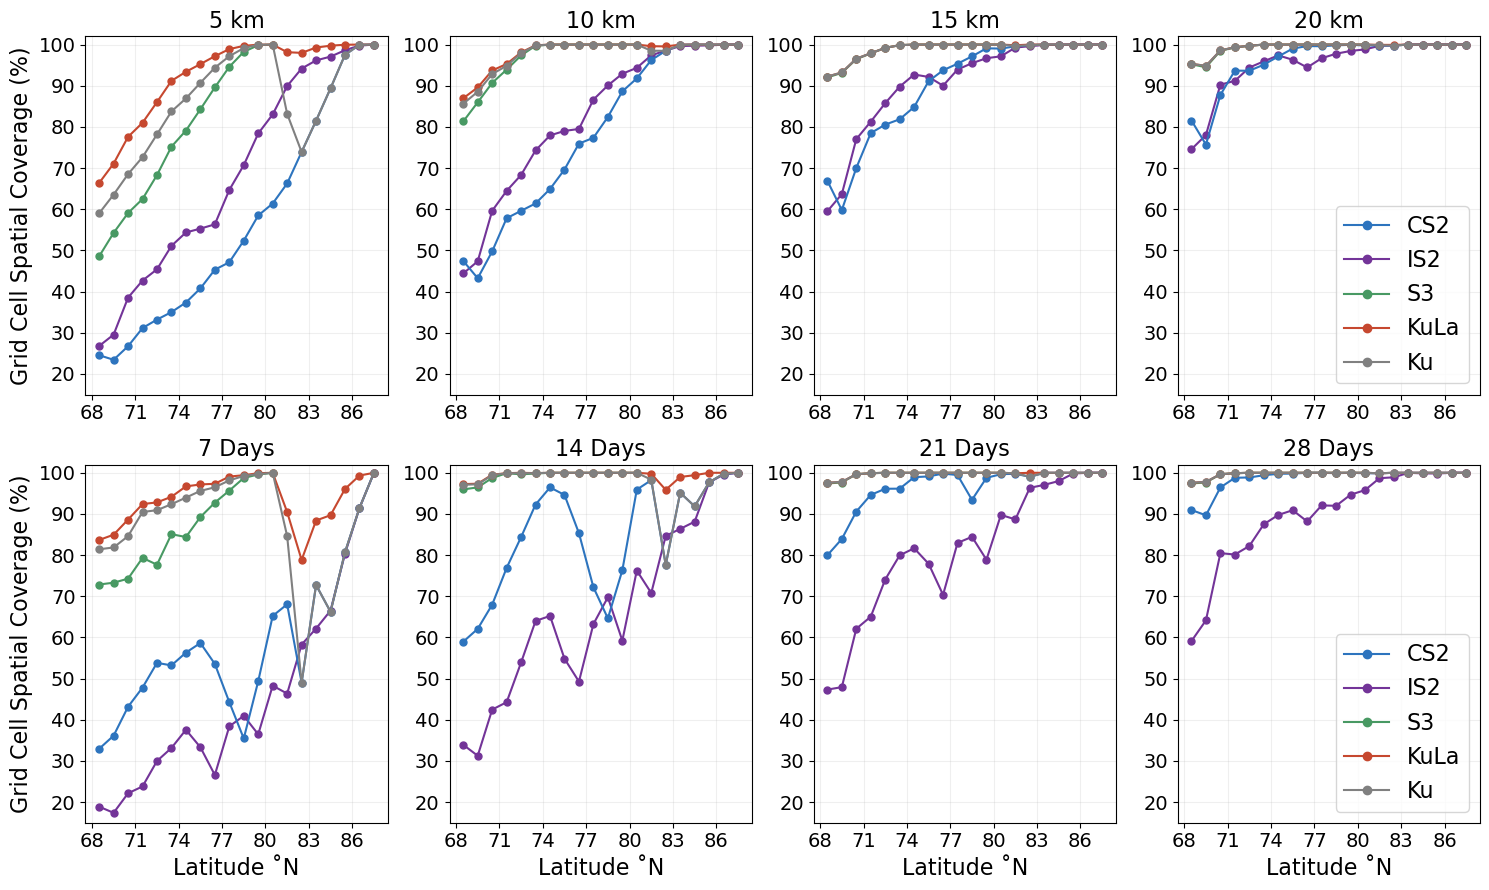

In [8]:
fig, ax = plt.subplots(2, 4, figsize=(15, 9))

cs2_lead_colour = '#2D74BE'
s3_lead_colour = '#489963'
is2_lead_colour = '#733498'
merged_lead_colour = '#C6482F'
modis_lead_colour = '#F0CF65'
ku_lead_colour = 'grey'

grid_colors = {'CS2': cs2_lead_colour, 'IS2': is2_lead_colour,
               'S3': s3_lead_colour, 'Merged': merged_lead_colour,
                'Ku':ku_lead_colour}

marker_size = 5

grid_sizes = {0:'5km',
              1:'10km',
              2:'15km',
              3:'20km'}

temporal_intervals = {0:'7Days',
                      1:'14Days',
                      2:'21Days',
                      3:'28Days'}

for position,size in grid_sizes.items():
    ax[0,position].plot(is2_grid_values[size]['Lat Band'], is2_grid_values[size]['Percentage Valid'],
              color=grid_colors['IS2'], markersize=marker_size, marker='o', linestyle='-')
    ax[0,position].plot(cs2_grid_values[size]['Lat Band'], cs2_grid_values[size]['Percentage Valid'],
              color=grid_colors['CS2'], markersize=marker_size, marker='o', linestyle='-')
    ax[0,position].plot(s3_grid_values[size]['Lat Band'], s3_grid_values[size]['Percentage Valid'],
              color=grid_colors['S3'], markersize=marker_size, marker='o', linestyle='-')
    ax[0,position].plot(merged_grid_values[size]['Lat Band'], merged_grid_values[size]['Percentage Valid'],
              color=grid_colors['Merged'], markersize=marker_size, marker='o', linestyle='-')
    ax[0,position].plot(ku_grid_values[size]['Lat Band'], ku_grid_values[size]['Percentage Valid'],
              color=grid_colors['Ku'], markersize=marker_size, marker='o', linestyle='-')

for position,interval in temporal_intervals.items():
    ax[1,position].plot(is2_interval_values[interval]['Lat Band'], is2_interval_values[interval]['Percentage Valid'],
              color=grid_colors['IS2'], markersize=marker_size, marker='o', linestyle='-')
    ax[1,position].plot(cs2_interval_values[interval]['Lat Band'], cs2_interval_values[interval]['Percentage Valid'],
              color=grid_colors['CS2'], markersize=marker_size, marker='o', linestyle='-')
    ax[1,position].plot(s3_interval_values[interval]['Lat Band'], s3_interval_values[interval]['Percentage Valid'],
              color=grid_colors['S3'], markersize=marker_size, marker='o', linestyle='-')
    ax[1,position].plot(merged_interval_values[interval]['Lat Band'], merged_interval_values[interval]['Percentage Valid'],
              color=grid_colors['Merged'], markersize=marker_size, marker='o', linestyle='-')
    ax[1,position].plot(ku_interval_values[interval]['Lat Band'], ku_interval_values[interval]['Percentage Valid'],
              color=grid_colors['Ku'], markersize=marker_size, marker='o', linestyle='-')

for a in ax.flat:
    a.xaxis.grid(True, 'major', alpha=0.2)
    a.yaxis.grid(True, 'major', alpha=0.2)
    a.set_ylim(15,102)
    a.tick_params(axis='both', which='major', labelsize=14)
    a.set_xticks(np.arange(-0.5, 18, 3))
    a.set_xticklabels([68,71,74,77,80,83,86])

ax[0,0].set_ylabel('Grid Cell Spatial Coverage (%)', fontsize=16)
ax[1,0].set_ylabel('Grid Cell Spatial Coverage (%)', fontsize=16)

ax[1,0].set_xlabel('Latitude ˚N', fontsize=16)
ax[1,1].set_xlabel('Latitude ˚N', fontsize=16)
ax[1,2].set_xlabel('Latitude ˚N', fontsize=16)
ax[1,3].set_xlabel('Latitude ˚N', fontsize=16)

ax[0,0].set_title('5 km',fontsize=16)
ax[0,1].set_title('10 km',fontsize=16)
ax[0,2].set_title('15 km',fontsize=16)
ax[0,3].set_title('20 km',fontsize=16)
ax[1,0].set_title('7 Days',fontsize=16)
ax[1,1].set_title('14 Days',fontsize=16)
ax[1,2].set_title('21 Days',fontsize=16)
ax[1,3].set_title('28 Days',fontsize=16)

legend_elements = [Line2D([0], [0], color=cs2_lead_colour, marker='o', linestyle='-', label='CS2'),
    Line2D([0], [0], color=is2_lead_colour, marker='o', linestyle='-', label='IS2'),
    Line2D([0], [0], color=s3_lead_colour, marker='o', linestyle='-', label='S3'),
    Line2D([0], [0], color=merged_lead_colour, marker='o', linestyle='-', label='KuLa'),
    Line2D([0], [0], color=ku_lead_colour, marker='o', linestyle='-', label='Ku')]
ax[0,3].legend(handles=legend_elements, loc='lower right', fontsize=16)
ax[1,3].legend(handles=legend_elements, loc='lower right', fontsize=16)

plt.tight_layout()
plt.show()

fig.savefig('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Arctic_Lead_Density/Figures/Fig5.png',dpi=300,bbox_inches="tight")

# Stats

In [40]:
ku_interval_values['7Days']

,Lat Band,Total Cells,Valid Cells,Percentage Valid
0,68-69,619,504,81.421648
1,69-70,678,555,81.858407
2,70-71,871,737,84.615385
3,71-72,987,893,90.476190
4,72-73,1057,961,90.917692
5,73-74,1167,1078,92.373608
6,74-75,1211,1138,93.971924
7,75-76,1023,978,95.601173
8,76-77,1049,1012,96.472831
9,77-78,1086,1066,98.158379


In [41]:
merged_interval_values['7Days']

,Lat Band,Total Cells,Valid Cells,Percentage Valid
0,68-69,619,518,83.683360
1,69-70,678,576,84.955752
2,70-71,871,772,88.633754
3,71-72,987,912,92.401216
4,72-73,1057,981,92.809839
5,73-74,1167,1099,94.173093
6,74-75,1211,1171,96.696945
7,75-76,1023,994,97.165200
8,76-77,1049,1021,97.330791
9,77-78,1086,1076,99.079190


In [35]:
ku_grid_values['5km']

,Lat Band,Total Cells,Valid Cells,Percentage Valid
0,68-69,20299,4982,24.543081
1,69-70,23182,5432,23.431973
2,70-71,28521,7622,26.724168
3,71-72,30755,9578,31.142904
4,72-73,32293,10720,33.196049
5,73-74,34402,12045,35.012499
6,74-75,35248,13163,37.343963
7,75-76,30048,12251,40.771432
8,76-77,30216,13693,45.317051
9,77-78,30179,14221,47.122171
